# Clustering

* Read the ISLR book.
* K-Means - 10.1
* Hierarchical - 10.3.2
* Agglomerative - 10.11

In [31]:
import pandas as pd
from dask.array import corrcoef
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

cluster_colours = ['red', 'green', 'blue', 'orange', 'violet', 'yellow']

# plot the starting cut
def plot(X=None, title=None, labels=None):
    plt.figure(figsize=(10,4))
    #cmap="Set1"
    #cmap="tab10"
    cmap=mpl.colors.ListedColormap(cluster_colours)
    norm=mpl.colors.BoundaryNorm(range(0,len(cluster_colours)), cmap.N)
    if labels is None:
        plt.scatter(X[:,0], X[:,1], s=1, color="blue")
    else:
        plt.scatter(X[:,0], X[:,1], s=1, c=labels, cmap=cmap, norm=norm)
    plt.title(title)
    plt.colorbar()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# https://xkcd.com/221/ - 4 is overused
random_seed = 221

In [32]:
import numpy as np

nci_data = pd.read_csv("ass2_data_2026/part2/nci60_data.csv", index_col=0)
X = scale(nci_data.T)
P = PCA().fit_transform(X)

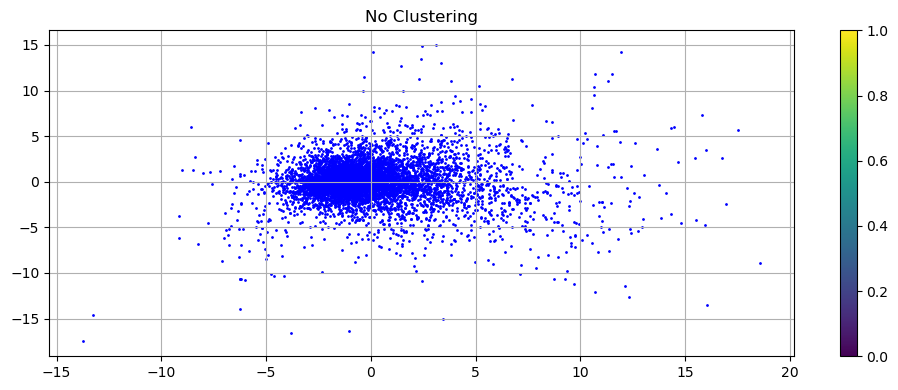

[0 1 2]


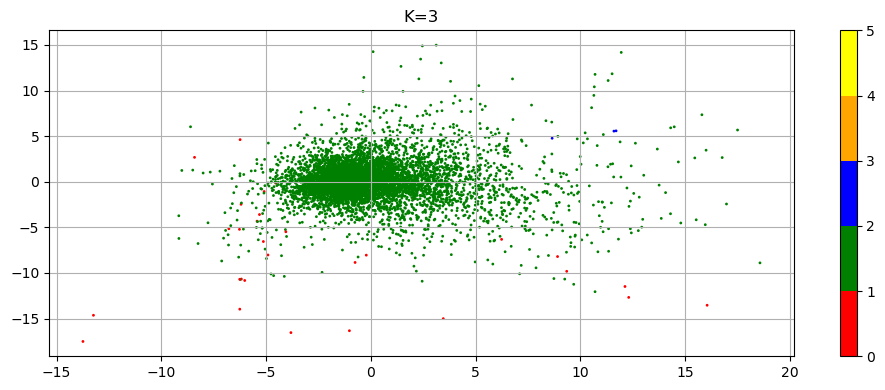

[0 1 2 3]


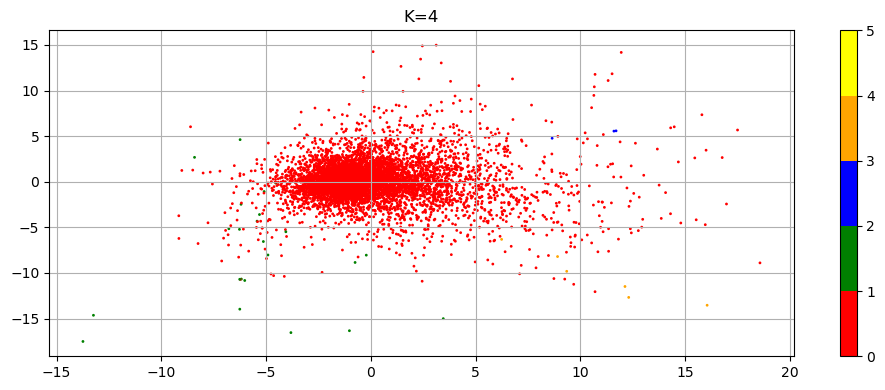

[0 1 2 3 4]


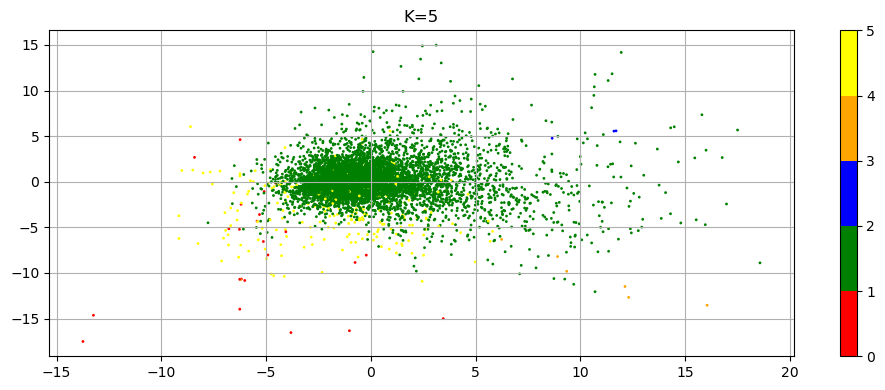

[0 1 2 3 4 5]


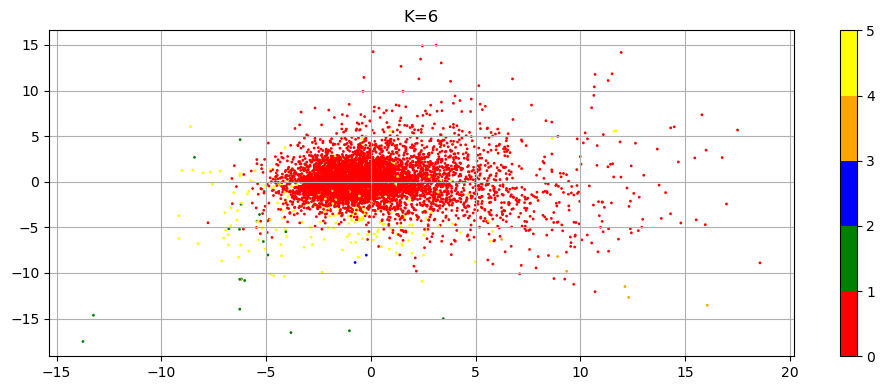

In [37]:
import matplotlib as mpl

cut = P[:,0:2] # inclusive of beginning, exclusive of ending.

plot(cut, title="No Clustering")

# hierarchical clustering with Euclidean distance and complete linkage

metric = 'euclidean'
linkage = 'complete'

for k in range(3,7):
    model = AgglomerativeClustering(
        n_clusters=k, metric=metric, linkage=linkage)
    labels = model.fit_predict(X)
    print(np.unique(labels))
    plot(X=cut, labels=labels, title=f"K={k}")

# hierarchical clustering with Euclidean distance and complete linkage

## What can you deduce/observe about the clustering?


[0 1 2]


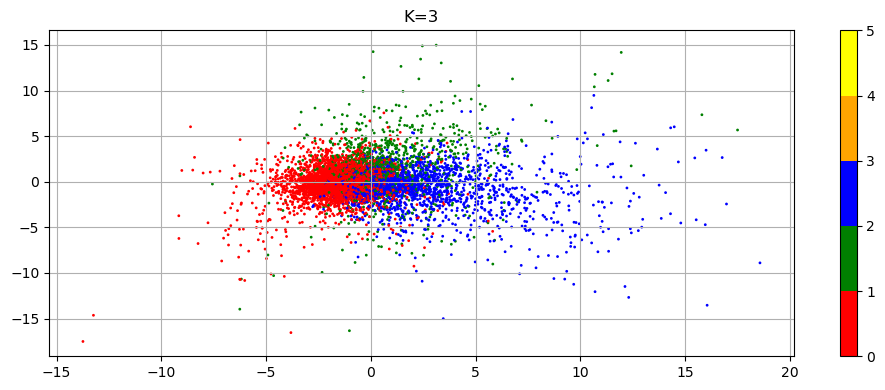

[0 1 2 3]


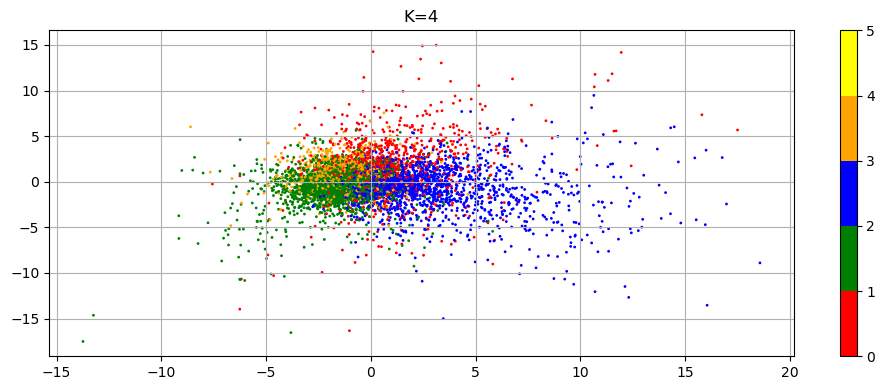

[0 1 2 3 4]


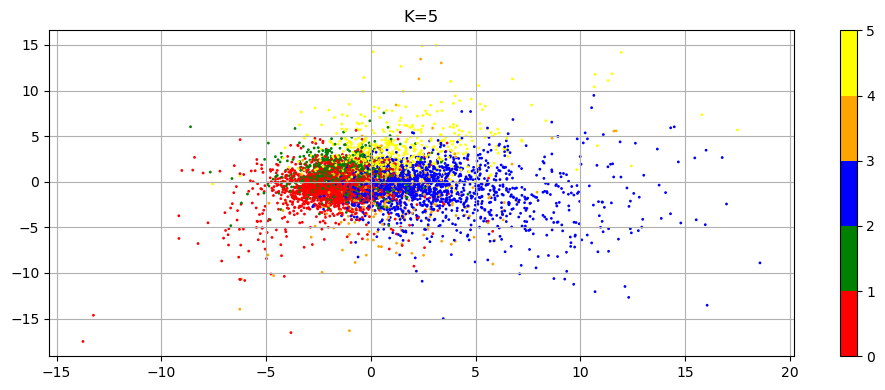

[0 1 2 3 4 5]


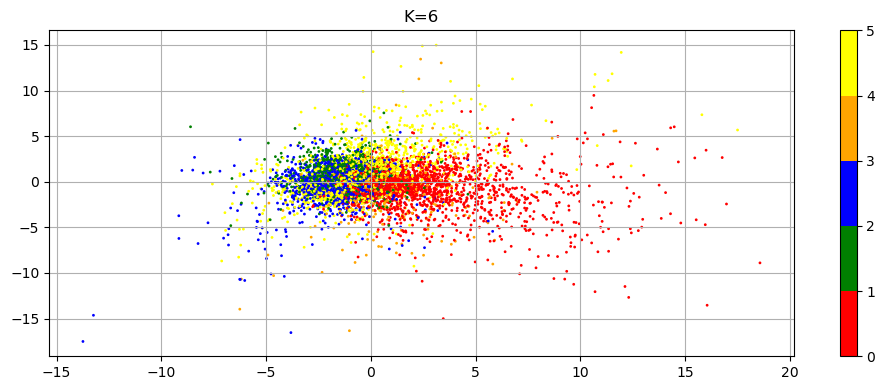

In [38]:
# use correlation based distance and complete linkage.

cut = P[:,0:2] # inclusive of beginning, exclusive of ending.

# distance = 1-corr(x,y)
# Now, is this X.corr, X.T.corr, or corrcoef(X)?
# corrcoef(x) assumes transpose by default.
# X.corr is only on a dataframe, not a ndarray.
distance = 1 - np.corrcoef(X)

metric = 'precomputed'
linkage = 'complete'

for k in range(3,7):
    model = AgglomerativeClustering(
        n_clusters=k, metric=metric, linkage=linkage)
    labels = model.fit_predict(distance)
    print(np.unique(labels))
    plot(X=cut, labels=labels, title=f"K={k}")



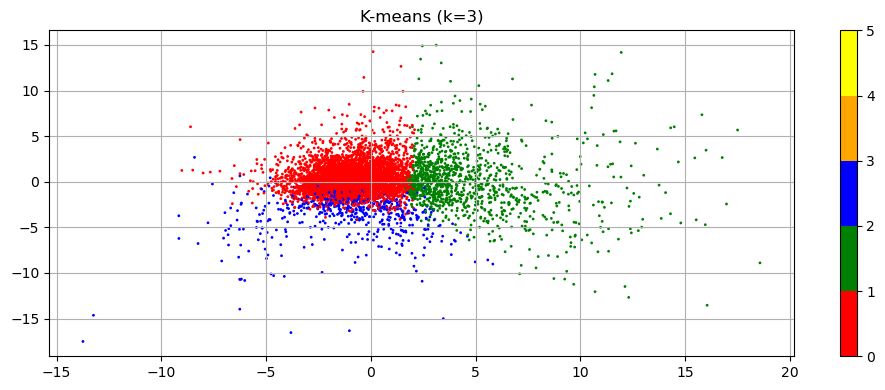

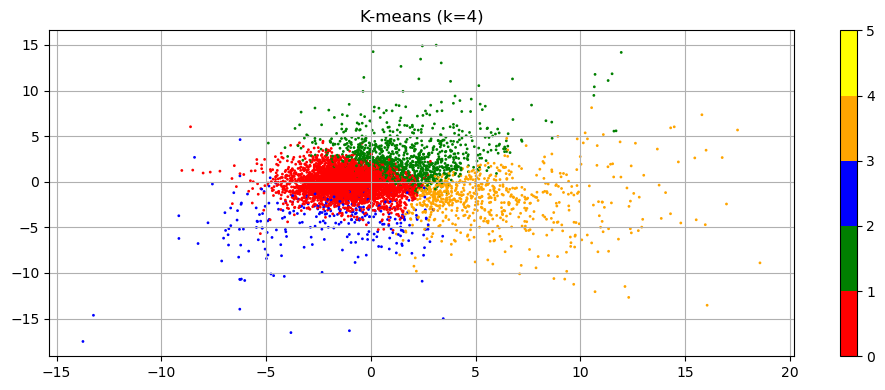

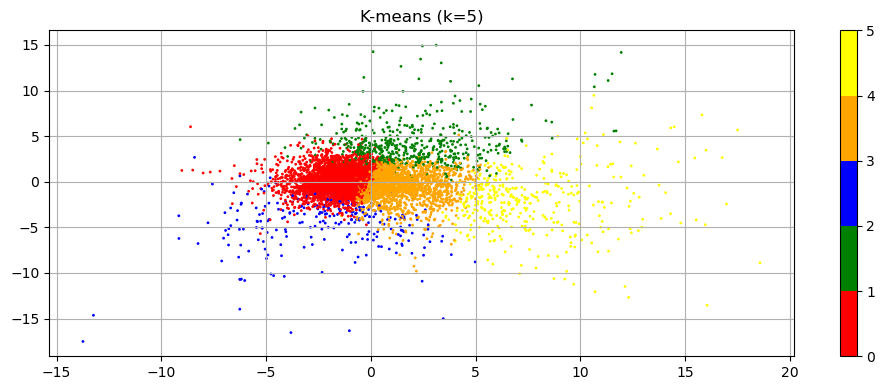

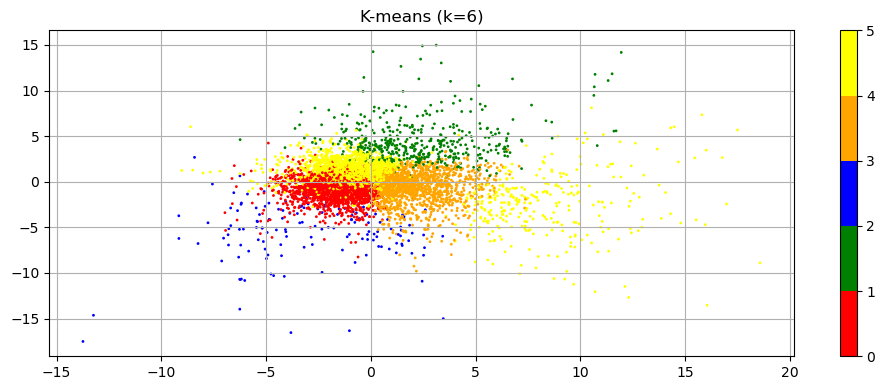

In [39]:
from sklearn.cluster import KMeans
# Perform k-means for 3-6 clusters.

for K in [3,4,5,6] :
    # Fit K-means and get labels
    model = KMeans(n_clusters=K, random_state=random_seed).fit(X)
    labels = model.labels_
    centers = model.cluster_centers_
    plot(X=cut, labels=labels, title=f"K-means (k={K})")


